In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd
import random
import pickle
import math
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix,f1_score
import sys
path = r"C:\Users\s625340\Documents\Notebooks\Package_public\src" # Mettre ici le chemin du dossier src en local # Put the lore src folder path here  
sys.path.insert(0, path) 
import dbiForestOnline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Exemple simple d'utilisation de la dbiForest 
# Simple example of an application of dbiForest

In [8]:
### Création de données exemple simple avec des données multivariées normales centrées en zéro et des anomalies énormément dispersées en 1000
#Creation of a simple example dataset with multivariate data normally distributed around zero and anomalies highly dispersed around 1000.
rng = np.random.default_rng()
epsilon = 0.05 
n_samples = 500
n_features = 100
n_anomalies = int(epsilon * n_samples)

n_normal = n_samples - n_anomalies

X_normal = rng.multivariate_normal(mean=np.zeros(n_features),cov=np.eye(n_features),size=n_normal)

mu = np.full(n_features, 1000)


Sigma = 100 * np.eye(n_features)

X_anomaly = rng.multivariate_normal(
mean=mu,
cov=Sigma,
size=n_anomalies)

X = np.vstack([X_normal, X_anomaly])

y = np.hstack([
np.zeros(n_normal, dtype=int),
np.ones(n_anomalies, dtype=int)
])

columns = [f"x{i}" for i in range(n_features)]
df = pd.DataFrame(X, columns=columns)
df["is_anomaly"] = y

In [9]:
df

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x91,x92,x93,x94,x95,x96,x97,x98,x99,is_anomaly
0,1.902497,-0.211939,1.816641,-0.695321,-0.228705,0.494249,-0.481110,0.133869,0.109086,0.076590,...,0.512482,-0.540218,0.046108,-0.555455,-0.273099,0.416643,1.290688,0.123690,-0.793022,0
1,1.073543,-1.017989,1.685489,-0.266534,1.567815,0.648464,-0.710586,1.676115,-1.124139,0.827894,...,0.431209,-0.339405,2.188361,-0.245169,-0.116752,-1.511096,-0.680778,-1.826490,-0.836707,0
2,-1.819201,0.403498,0.958860,0.739532,-0.805950,0.070507,1.016991,1.231468,1.259608,-0.879728,...,1.068825,0.836163,0.203144,-1.667723,-0.394370,1.155299,-0.266242,0.697092,0.833367,0
3,0.365008,1.860711,0.245484,0.107891,-1.591550,1.321993,-0.014840,-0.053964,0.638086,0.691899,...,-0.600690,-2.063734,0.384697,-1.666843,2.165916,-0.112242,-0.271726,-1.255581,-2.624069,0
4,-0.487387,-0.077274,0.298541,1.637511,1.550440,1.023450,-0.110591,-0.587299,-0.972643,1.609743,...,-0.578468,0.230986,-0.211464,1.213611,-0.555813,1.508093,-0.380254,1.868941,-0.322780,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1000.849195,991.345889,992.008498,996.674857,991.069350,1009.236366,1023.823324,1000.772605,1010.700613,999.248366,...,1002.001123,999.451764,992.319235,1002.984794,1009.791936,995.717075,1000.655408,1016.510595,996.376238,1
496,999.632700,1003.262226,1013.077516,998.915370,1005.108711,1011.210082,978.463052,994.739801,1006.927150,1008.421130,...,1025.574026,986.711212,1001.452978,992.310456,1018.422846,1019.061533,1002.542562,1001.289847,995.417091,1
497,1005.085624,988.372043,986.283009,1004.620473,1004.721877,989.340375,996.811086,992.667320,1019.615577,1007.087008,...,987.003233,994.522446,994.063392,986.722549,991.252876,994.801416,1000.754821,1012.388362,977.453446,1
498,1015.672522,991.657711,1016.714725,999.952429,997.196349,1008.669758,1007.717526,1001.998895,1007.071868,1001.628321,...,995.573871,990.314058,989.101285,1015.658157,986.911086,1007.315637,986.581241,995.415021,983.275911,1


In [10]:
# Intialisation d'une dbiForest 
# Initialization of a dbiForest.
dbiForest = dbiForestOnline.IsolationForest_density_online(n_trees = 50,subsample_size= 0.75,dim=[1,3], epsilon= 0.05,n_try = 'sqrt')

In [11]:
dbiForest.fit(X)

Arbre numéro [0] 
Arbre numéro [1] 
Arbre numéro [2] 
Arbre numéro [3] 
Arbre numéro [4] 
Arbre numéro [5] 
Arbre numéro [6] 
Arbre numéro [7] 
Arbre numéro [8] 
Arbre numéro [9] 
Arbre numéro [10] 
Arbre numéro [11] 
Arbre numéro [12] 
Arbre numéro [13] 
Arbre numéro [14] 
Arbre numéro [15] 
Arbre numéro [16] 
Arbre numéro [17] 
Arbre numéro [18] 
Arbre numéro [19] 
Arbre numéro [20] 
Arbre numéro [21] 
Arbre numéro [22] 
Arbre numéro [23] 
Arbre numéro [24] 
Arbre numéro [25] 
Arbre numéro [26] 
Arbre numéro [27] 
Arbre numéro [28] 
Arbre numéro [29] 
Arbre numéro [30] 
Arbre numéro [31] 
Arbre numéro [32] 
Arbre numéro [33] 
Arbre numéro [34] 
Arbre numéro [35] 
Arbre numéro [36] 
Arbre numéro [37] 
Arbre numéro [38] 
Arbre numéro [39] 
Arbre numéro [40] 
Arbre numéro [41] 
Arbre numéro [42] 
Arbre numéro [43] 
Arbre numéro [44] 
Arbre numéro [45] 
Arbre numéro [46] 
Arbre numéro [47] 
Arbre numéro [48] 
Arbre numéro [49] 


In [12]:
# Obtention des prédictions binaires
# Obtaining binary predictions
y_pred = dbiForest.predict(X)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [13]:
print(f"Accuracy : {accuracy_score(y, y_pred):.4f}")
print(f"Precision : {precision_score(y, y_pred):.4f}")
print(f"Recall : {recall_score(y, y_pred):.4f}")
print(f"F1-score : {f1_score(y, y_pred):.4f}")
print("\nConfusion matrix:")
print(confusion_matrix(y, y_pred))

Accuracy : 1.0000
Precision : 1.0000
Recall : 1.0000
F1-score : 1.0000

Confusion matrix:
[[475   0]
 [  0  25]]


In [14]:
# Obtention des profondeur avec la dbiForest
# Obtaining depths with the dbiForest
depths = dbiForest.generate_profondeurs(X)



In [15]:
# Attention, les colonnes correspondent aux individus et les lignes à la profondeur attribué par arbre
# Warning, columns correspond to observations and rows correspond to the depths assigned by each tree
print(depths.shape)
depths

(50, 500)


,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,9.0,3.0,14.0,15.0,12.0,9.0,10.0,15.0,15.0,10.0,...,9.0,8.0,9.0,8.0,2.0,4.0,8.0,8.0,8.0,7.0
1,10.0,15.0,17.0,17.0,19.0,18.0,20.0,23.0,20.0,8.0,...,6.0,4.0,8.0,2.0,4.0,5.0,8.0,5.0,5.0,8.0
2,21.0,11.0,17.0,11.0,10.0,16.0,8.0,10.0,12.0,7.0,...,9.0,9.0,4.0,8.0,9.0,4.0,4.0,5.0,9.0,2.0
3,19.0,17.0,13.0,16.0,8.0,18.0,13.0,16.0,11.0,18.0,...,5.0,10.0,2.0,5.0,5.0,5.0,10.0,5.0,3.0,5.0
4,15.0,15.0,25.0,27.0,20.0,13.0,8.0,24.0,27.0,16.0,...,12.0,9.0,12.0,7.0,7.0,3.0,10.0,4.0,9.0,3.0
5,21.0,13.0,17.0,11.0,6.0,10.0,24.0,11.0,15.0,13.0,...,3.0,3.0,6.0,5.0,4.0,5.0,4.0,4.0,7.0,3.0
6,31.0,15.0,27.0,16.0,19.0,20.0,22.0,22.0,24.0,18.0,...,6.0,8.0,7.0,8.0,2.0,7.0,7.0,7.0,8.0,6.0
7,14.0,14.0,23.0,12.0,14.0,28.0,13.0,14.0,17.0,5.0,...,6.0,3.0,4.0,6.0,8.0,11.0,2.0,7.0,7.0,7.0
8,19.0,18.0,11.0,18.0,14.0,12.0,16.0,16.0,18.0,10.0,...,4.0,6.0,2.0,3.0,2.0,10.0,2.0,4.0,8.0,3.0
9,11.0,10.0,15.0,13.0,11.0,15.0,15.0,10.0,11.0,12.0,...,7.0,4.0,3.0,7.0,7.0,5.0,5.0,3.0,8.0,3.0


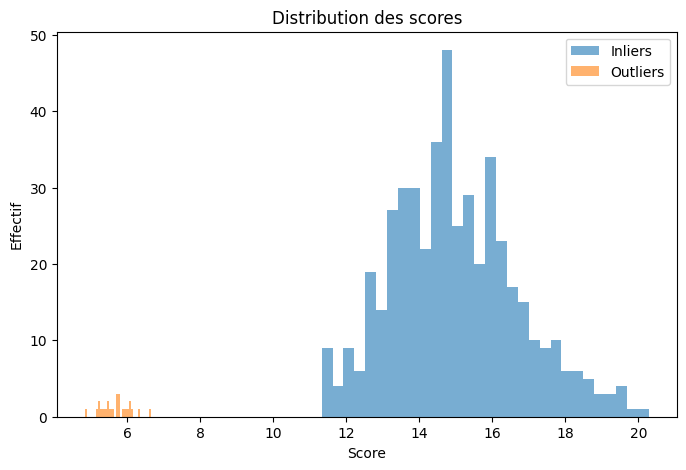

In [16]:
# Un exemple d'affichage des profondeurs inliers vs outliers 
# A visualization of inlier depths vs outlier depths
import matplotlib.pyplot as plt

mean_depths = depths.mean(axis=0).values

mean_depths_inliers = mean_depths[y == 0]
mean_depths_outliers = mean_depths[y == 1]

plt.figure(figsize=(8, 5))

plt.hist(mean_depths_inliers, bins=30, alpha=0.6, label="Inliers")
plt.hist(mean_depths_outliers, bins=30, alpha=0.6, label="Outliers")

plt.xlabel("Score")
plt.ylabel("Effectif")
plt.title("Distribution des scores")
plt.legend()

plt.show()

# Exemple simple de récolte des importances des variables 
# Simple example of the use of dbiForest variable importance

In [17]:
df_all_ranks = []
plot_rang = False

num_forest = 0   # compteur global des forêts générées # Global counter for generated forests


utilisations_dbi = dbiForestOnline.recuperation_features_used_forest(dbiForest)
if utilisations_dbi.empty:
    print(f"échec {type_val}")
rang = dbiForestOnline.importance_variables(
    utilisations_dbi,
    dbiForest.threshold_mean,
)

In [18]:
rang
# Le numéro de élément correspond à l'index de la variable dans le dataframe d'entrainement
# PLus rang moyen est élevé, plus la variable est importante, rang_moyen = 100 signifie que la variable est sélectionné 100% du temps
# The element number corresponds to the index of the variable in the training dataframe
# The higher the average rank, the more important the variable, an average rank of 100 means that the variable is selected 100% of the time

,element,rang_moyen
34,34,9.833333
82,82,19.500000
46,46,21.333333
71,71,21.333333
90,90,22.000000
...,...,...
14,14,74.000000
50,50,79.000000
52,52,84.666667
75,75,84.833333


In [19]:
utilisations_dbi
# Retenue = la combinaison utilisé pour une coupure
# Combinaison = une combinaison proposé pour la coupure
# Qualite = le score attribué à la combinaison
# depth = la profondeur du noeud 

# Selected = the combination used for the split
# Combination = a candidate combination for the split
# Quality = the score assigned to the combination
# Depth = the depth of the node

,depth,retenue,Combinaison 0,Qualite 0,Combinaison 1,Qualite 1,Combinaison 2,Qualite 2,Combinaison 3,Qualite 3,...,Combinaison 5,Qualite 5,Combinaison 6,Qualite 6,Combinaison 7,Qualite 7,Combinaison 8,Qualite 8,Combinaison 9,Qualite 9
0,7,"[7, 58, 81]","[2, 40, 81]",0.642857,"[7, 58, 81]",0.900000,"[3, 5, 71]",0.657143,"[28, 30, 76]",0.315789,...,"[54, 81, 86]",0.450000,"[25, 66, 87]",0.200000,"[2, 9, 53]",0.689655,"[45, 74, 91]",0.333333,"[12, 77, 79]",0.373219
1,6,"[4, 97]","[4, 97]",0.962121,"[57, 80]",0.512060,"[0, 66]",0.641439,"[28, 36]",0.343801,...,"[12, 38]",0.254069,"[45, 92]",0.521665,"[73, 81]",0.754607,"[45, 95]",0.304315,"[20, 96]",0.273392
2,5,"[7, 26, 29]","[8, 21, 35]",0.281627,"[30, 39, 51]",0.138710,"[15, 19, 59]",0.349998,"[17, 36, 54]",0.250834,...,"[0, 46, 49]",0.277456,"[6, 13, 68]",0.311923,"[77, 82, 86]",0.188148,"[7, 26, 29]",0.671915,"[14, 78, 90]",0.284310
3,7,[64],[45],0.963871,[64],0.980749,[45],0.963871,[28],0.827673,...,[56],0.484847,[50],0.849320,[40],0.674052,[62],0.149658,[19],0.923506
4,8,"[49, 70, 78]","[0, 23, 55]",0.555556,"[25, 45, 86]",0.048387,"[79, 90, 96]",0.140351,"[24, 81, 87]",0.307692,...,"[35, 57, 77]",0.571429,"[48, 49, 87]",0.542857,"[49, 70, 78]",0.586207,"[4, 56, 64]",0.406250,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11720,4,"[9, 89]","[44, 63]",0.016606,"[9, 89]",0.037943,"[28, 62]",0.028008,"[25, 67]",0.031495,...,"[27, 53]",0.026534,"[13, 73]",0.024619,"[15, 58]",0.020432,"[75, 93]",0.025150,"[32, 34]",0.027457
11721,3,"[5, 82]","[14, 95]",0.035165,"[93, 95]",0.023765,"[44, 62]",0.028038,"[59, 66]",0.024255,...,"[5, 82]",0.048637,"[30, 55]",0.024864,"[18, 71]",0.022316,"[5, 43]",0.033933,"[94, 99]",0.025763
11722,2,[80],[51],0.052182,[21],0.052255,[58],0.053861,[71],0.056001,...,[23],0.029841,[6],0.072362,[80],0.086100,[87],0.051855,[98],0.031531
11723,1,"[70, 82]","[70, 82]",0.030535,"[24, 66]",0.024962,"[29, 35]",0.015495,"[48, 70]",0.018063,...,"[2, 9]",0.015642,"[23, 51]",0.016290,"[54, 73]",0.018749,"[11, 12]",0.011531,"[2, 4]",0.021762


# Exemple de mise à jour online
# Example of an online update

In [20]:
dbiForest.maj_online(X, seuil_fusion=50,window_size = [50])

in maj_online


In [21]:
# Toutes les fonctions précédentes sont exactement identifiques pour la forêt avant et après mise à jour, les fonctions de scores et importances 
# ne changent pas 
# All the previous functions are exactly the same for the forest before and after the update; the scores and feature importances functions do not change